# Task
Use Zero-shot and Few-Shot using llama3.2 and evaluate the results on both the `test_easy` and `test_hard` sets.

**Reasoning:**

We run and evaluate both zero-shot and few-shot to compare it to our fine-tuned model and see whether our model performed better

## Prevent warnings

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## import and pull llama3.2

In [7]:
import ollama

print("Downloading llama3...")
ollama.pull('llama3.2')
print("Download complete!")

Download complete!


## Evaluation function

In [9]:
import json
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_predictions(results_path):
    """
    Evaluates predictions from a JSON file with keys: 'truth', 'prediction', 'correct'.
    """
    print(f"--- Loading results from: {results_path} ---")
    
    with open(results_path, "r", encoding="utf-8") as f:
        results = json.load(f)

    y_true = []
    y_pred = []
    valid_count = 0

    for item in results:
        # Match keys to your specific file structure: "truth" and "prediction"
        gt = item.get("truth")
        pred = item.get("prediction")
        
        # Ensure we have both values before adding to the list
        if gt is None or pred is None:
            continue
        
        y_true.append(gt)
        y_pred.append(pred)
        valid_count += 1

    if valid_count == 0:
        print("No valid 'truth'/'prediction' pairs found in the file.")
        return

    # --- Calculation ---
    
    # 1. Accuracy (Top-1)
    acc = accuracy_score(y_true, y_pred)

    # 2. Precision, Recall, F1
    # 'weighted' accounts for class imbalance
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    # --- Output Report ---
    print("\n" + "="*35)
    print("        EVALUATION REPORT        ")
    print("="*35)
    print(f"Total Examples:       {valid_count}")
    print(f"Accuracy:             {acc:.2%}")
    print("-" * 35)
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted):    {recall:.4f}")
    print(f"F1 Score (weighted):  {f1:.4f}")
    print("="*35)

## Baseline - Zero shot


In [11]:
def classify_with_zero_shot(ticket_text, components,correct):
    components_context = "\n".join([f"- {c['name']}: {c['description']}" for c in components])
    comp_names_list = [c['name'] for c in components]

    prompt = f"""
    You are an expert enterprise support triage system.

    TASK:
    Identify which technical component is most likely responsible for the issue.

    CANDIDATE COMPONENTS (Name: Description)
    {components_context}

    RULES:
    - Choose exactly ONE component from the list.
    - Output ONLY the component name.
    - No explanations.
    - No punctuation (like periods) or markdown.
    - Your output must be exactly one of these: {comp_names_list}

    SUPPORT TICKET:
    {ticket_text}
    """

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0}
    )

    pred = response["message"]["content"].strip()

    return (pred,pred==correct)

## Zero shot test - Easy

In [13]:
import json

with open('test_easy.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    ticket = item['user_complaint']['user_complaint']

    components = item['workflow']['workflow_components']

    correct_answer = item['malfunction']['affected_component']['name']

    pred, was_right = classify_with_zero_shot(ticket, components, correct_answer)

    count += was_right

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_answer
    })
print(f"Done classification on {total_examples} items...\n")

output_filename = "easy_zero_pred.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4)

Starting classification on 200 items...

Done classification on 200 items...



## Zero shot evaluation - Easy

--- Loading results from: easy_zero_pred.json ---

        EVALUATION REPORT        
Total Examples:       200
Accuracy:             66.50%
-----------------------------------
Precision (weighted): 0.6636
Recall (weighted):    0.6650
F1 Score (weighted):  0.6285


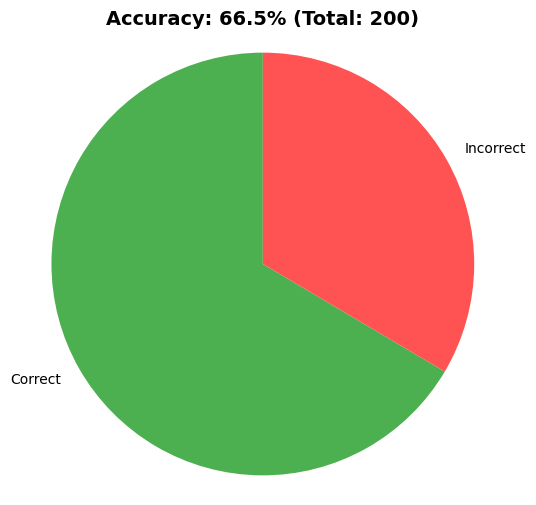

In [15]:
import matplotlib.pyplot as plt

evaluate_predictions("easy_zero_pred.json")

# Calculate the accuracy percentage
accuracy_percentage = (count / total_examples) * 100 if total_examples > 0 else 0
incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))

# Removed 'autopct' so percentages do not appear on the slices
plt.pie(sizes, labels=labels, colors=colors, startangle=90)

# Added the accuracy percentage to the title
plt.title(f'Accuracy: {accuracy_percentage:.1f}% (Total: {total_examples})', fontsize=14, fontweight='bold')
plt.axis('equal')

plt.show()

## Zero shot test - Hard

In [17]:
import json

with open('test_hard_updatedv2.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    ticket = item['user_complaint']['user_complaint']

    components = item['workflow']['workflow_components']

    correct_answer = item['malfunction']['affected_component']['name']

    pred, was_right = classify_with_zero_shot(ticket, components, correct_answer)

    count += was_right

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_answer
    })
print(f"Done classification on {total_examples} items...\n")
output_filename = "hard_zero_pred.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4)

Starting classification on 200 items...

Done classification on 200 items...



## Zero shot evaluation - Hard

--- Loading results from: hard_zero_pred.json ---

        EVALUATION REPORT        
Total Examples:       200
Accuracy:             77.00%
-----------------------------------
Precision (weighted): 0.8609
Recall (weighted):    0.7700
F1 Score (weighted):  0.7646


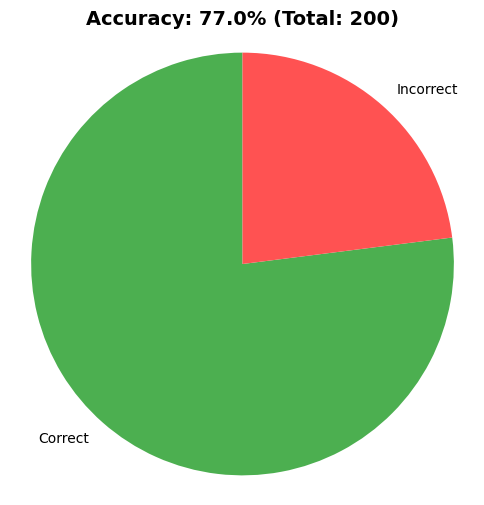

In [19]:
import matplotlib.pyplot as plt

evaluate_predictions("hard_zero_pred.json")

# Calculate the accuracy percentage
accuracy_percentage = (count / total_examples) * 100 if total_examples > 0 else 0
incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))

# Removed 'autopct' so percentages do not appear on the slices
plt.pie(sizes, labels=labels, colors=colors, startangle=90)

# Added the accuracy percentage to the title
plt.title(f'Accuracy: {accuracy_percentage:.1f}% (Total: {total_examples})', fontsize=14, fontweight='bold')
plt.axis('equal')

plt.show()

## Baseline - Few shot

In [21]:
import torch
def classify_with_few_shot(ticket_text, components_list,correct):

    components_context = "\n".join([f"- {c['name']}: {c['description']}" for c in components])
    comp_names_list = [c['name'] for c in components]

    examples = """
    ### EXAMPLE 1
    Ticket: "I have been using the Predictive Analytics Module for quite some time, and I must say that the recent erratic forecasts generated by the machine learning algorithms are highly concerning. The inaccurate risk assessments and suboptimal decision-making processes are causing significant financial losses and operational inefficiencies in the Agriculture industry. It's critical that this issue is addressed promptly to prevent further misleading insights hindering our informed business decisions."
    Correct Component: Predictive Analytics Module

    ### EXAMPLE 2
    Ticket: "I am extremely concerned about the intermittent failures in the data security and governance component. It's imperative that access control is consistently enforced to prevent unauthorized access to sensitive agricultural data. This is a serious security concern that needs urgent attention to avoid potential data breaches and ensure regulatory compliance!"
    Correct Component: Data Security and Governance
    """


    prompt = f"""
    You are an expert enterprise support triage system.

    TASK:
    Identify which technical component is most likely responsible for the issue.

    CANDIDATE COMPONENTS (Name: Description)
    {components_context}

    RULES:
    - Choose exactly ONE component from the list.
    - Output ONLY the component name.
    - No explanations.
    - No punctuation (like periods) or markdown.
    - Your output must be exactly one of these: {comp_names_list}

    ### CURRENT TASK
    Ticket: "{ticket_text}"
    Correct Component:
    """

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0}
    )

    pred = response["message"]["content"].strip()

    return (pred,pred==correct)

## Few shot test - Easy

In [23]:
with open('test_easy.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    ticket = item['user_complaint']['user_complaint']

    components = item['workflow']['workflow_components']

    correct_answer = item['malfunction']['affected_component']['name']

    pred, was_right = classify_with_few_shot(ticket, components, correct_answer)

    count += was_right

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_answer
    })

print(f"Done classification on {total_examples} items...\n")
output_filename = "easy_few_pred.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4)

Starting classification on 200 items...

Done classification on 200 items...



## Few shot evaluation - Easy

--- Loading results from: easy_few_pred.json ---

        EVALUATION REPORT        
Total Examples:       200
Accuracy:             72.50%
-----------------------------------
Precision (weighted): 0.7383
Recall (weighted):    0.7250
F1 Score (weighted):  0.6970


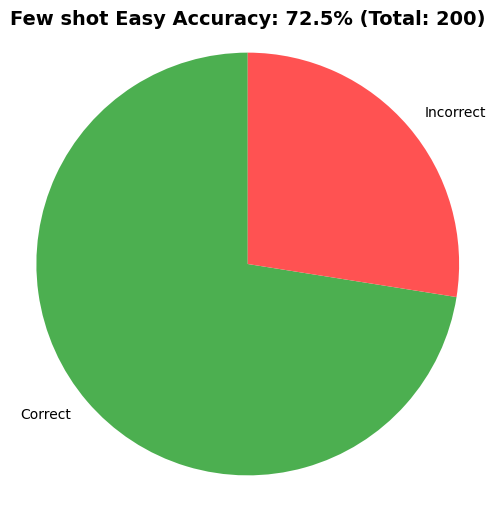

In [25]:
import matplotlib.pyplot as plt
evaluate_predictions("easy_few_pred.json")

# Calculate the accuracy percentage
accuracy_percentage = (count / total_examples) * 100 if total_examples > 0 else 0
incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))

# Removed 'autopct' so percentages do not appear on the slices
plt.pie(sizes, labels=labels, colors=colors, startangle=90)

# Added the accuracy percentage to the title
plt.title(f'Few shot Easy Accuracy: {accuracy_percentage:.1f}% (Total: {total_examples})', fontsize=14, fontweight='bold')
plt.axis('equal')

plt.show()

## Few shot test - Hard

In [27]:
with open('test_hard_updatedv2.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    ticket = item['user_complaint']['user_complaint']

    components = item['workflow']['workflow_components']

    correct_answer = item['malfunction']['affected_component']['name']

    pred, was_right = classify_with_few_shot(ticket, components, correct_answer)

    count += was_right

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_answer
    })

print(f"Done classification on {total_examples} items...\n")
output_filename = "hard_few_pred.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4)

Starting classification on 200 items...

Done classification on 200 items...



## Few shot evaluation - Hard

--- Loading results from: hard_few_pred.json ---

        EVALUATION REPORT        
Total Examples:       200
Accuracy:             74.50%
-----------------------------------
Precision (weighted): 0.8514
Recall (weighted):    0.7450
F1 Score (weighted):  0.7300


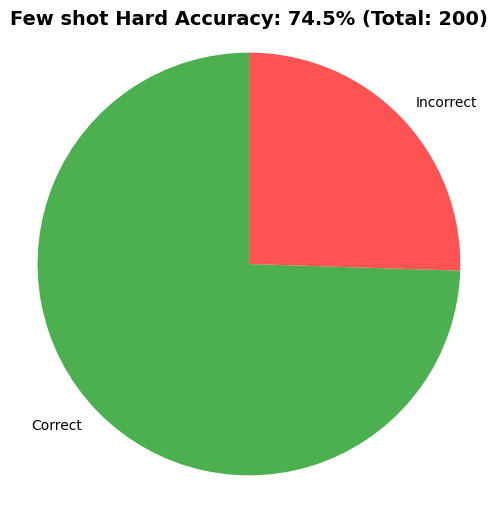

In [29]:
import matplotlib.pyplot as plt

evaluate_predictions("hard_few_pred.json")
# Calculate the accuracy percentage
accuracy_percentage = (count / total_examples) * 100 if total_examples > 0 else 0
incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))

# Removed 'autopct' so percentages do not appear on the slices
plt.pie(sizes, labels=labels, colors=colors, startangle=90)

# Added the accuracy percentage to the title
plt.title(f'Few shot Hard Accuracy: {accuracy_percentage:.1f}% (Total: {total_examples})', fontsize=14, fontweight='bold')
plt.axis('equal')

plt.show()